In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
fact_sales_df = pd.read_csv(
    r"C:\Data Analytics Projects\Cohort & Retention Analysis\Data\Cleaned\fact_sales.csv",
    parse_dates=["purchase_datetime"]
)

In [3]:
cltv_df = fact_sales_df[
    [
        "customer_key",
        "order_id",
        "purchase_datetime",
        "total_payment"
    ]
].copy()

In [4]:
cltv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110194 entries, 0 to 110193
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_key       110194 non-null  object        
 1   order_id           110194 non-null  object        
 2   purchase_datetime  110194 non-null  datetime64[ns]
 3   total_payment      110194 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 3.4+ MB


In [5]:
cltv_df.head()

,customer_key,order_id,purchase_datetime,total_payment
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,38.71
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,72.20
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,28.62


### Customer-Level Summary

In [6]:
customer_summary = (
    cltv_df
    .groupby('customer_key')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_revenue=('total_payment', 'sum'),
        first_purchase=('purchase_datetime', 'min'),
        last_purchase=('purchase_datetime', 'max')
    )
    .reset_index()
)

customer_summary.head()

,customer_key,total_orders,total_revenue,first_purchase,last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42


### Calculating Customer Lifespan

In [7]:
customer_summary['customer_lifespan_days'] = (
    customer_summary['last_purchase'] -
    customer_summary['first_purchase']
).dt.days

customer_summary.head()

,customer_key,total_orders,total_revenue,first_purchase,last_purchase,customer_lifespan_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,0
2,0000f46a3911fa3c0805444483337064,1,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,0


In [8]:
customer_summary['customer_lifespan_days'].describe()

count    93357.000000
mean         2.634061
std         24.955954
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        633.000000
Name: customer_lifespan_days, dtype: float64

### Calculating Average Order Value (AOV)
For each customer AOV = Total Revenue / Total Orders

In [9]:
customer_summary['average_order_value'] = (
    customer_summary['total_revenue'] /
    customer_summary['total_orders']
)

In [10]:
customer_summary[
    ['total_orders',
     'total_revenue',
     'average_order_value']
].head()

,total_orders,total_revenue,average_order_value
0,1,141.90,141.90
1,1,27.19,27.19
2,1,86.22,86.22
3,1,43.62,43.62
4,1,196.89,196.89


### Calculating Purchase Frequency
how many orders each customer has placed?

In [11]:
customer_summary['purchase_frequency'] = customer_summary['total_orders']

In [12]:
customer_summary[
    [
        'customer_key',
        'total_orders',
        'purchase_frequency'
    ]
].head()

,customer_key,total_orders,purchase_frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1
2,0000f46a3911fa3c0805444483337064,1,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,1
4,0004aac84e0df4da2b147fca70cf8255,1,1


### Calculating Historical CLTV

In [13]:
customer_summary['cltv'] = customer_summary['total_revenue']

In [14]:
customer_summary[
    [
        'customer_key',
        'total_orders',
        'total_revenue',
        'average_order_value',
        'purchase_frequency',
        'cltv'
    ]
].head()

,customer_key,total_orders,total_revenue,average_order_value,purchase_frequency,cltv
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1,196.89


### Customer Segmentation by CLTV
Dividing customers into Low, Medium, and High value groups based on their historical CLTV.

In [15]:
customer_summary['customer_segment'] = pd.qcut(
    customer_summary['cltv'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

In [16]:
customer_summary['customer_segment'].value_counts()

customer_segment
Low Value       31130
High Value      31114
Medium Value    31113
Name: count, dtype: int64

In [17]:
segment_counts = (
    customer_summary['customer_segment']
    .value_counts()
    .sort_index()
    .reset_index()
)

segment_counts.columns = ['customer_segment', 'customers']

segment_counts

,customer_segment,customers
0,Low Value,31130
1,Medium Value,31113
2,High Value,31114


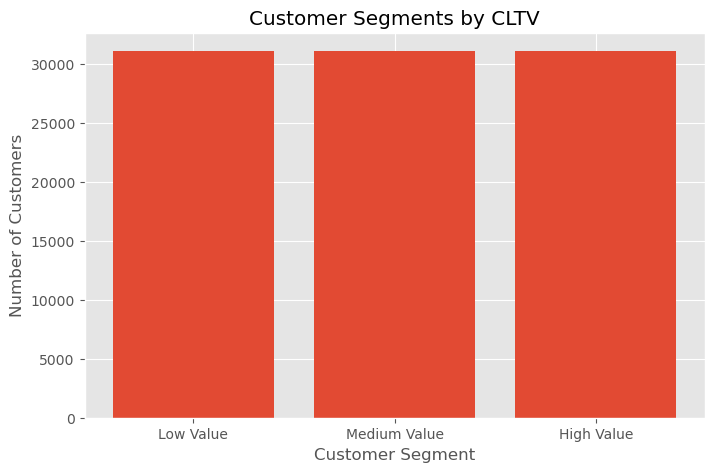

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_counts['customer_segment'],
    segment_counts['customers']
)

plt.title('Customer Segments by CLTV')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.show()

### Top Customers by CLTV

In [19]:
top_customers = (
    customer_summary
    .sort_values('cltv', ascending=False)
    .head(10)
)

top_customers[
    ['customer_key', 'total_orders', 'cltv']
]

,customer_key,total_orders,cltv
3724,0a0a92112bd4c708ca5fde585afaa872,1,109312.64
38579,698e1cf81d01a3d389d96145f7fa6df8,1,45256.00
71565,c402f431464c72e27330a67f7b94d4fb,1,44048.00
23411,4007669dec559734d6f53e029e360987,1,36489.24
87447,ef8d54b3797ea4db1d63f0ced6a906e9,1,30186.00
43168,763c8b1c9c68a0229c42c9fc6f662b93,1,29099.52
73126,c8460e4251689ba205045f3ea17884a1,4,27935.46
85764,eae0a83d752b1dd32697e0e7b4221656,2,25051.89
22395,3d47f4368ccc8e1bb4c4a12dbda7111b,1,22346.60
63527,adfa1cab2b2c8706db21bb13c0a1beb1,1,19457.04


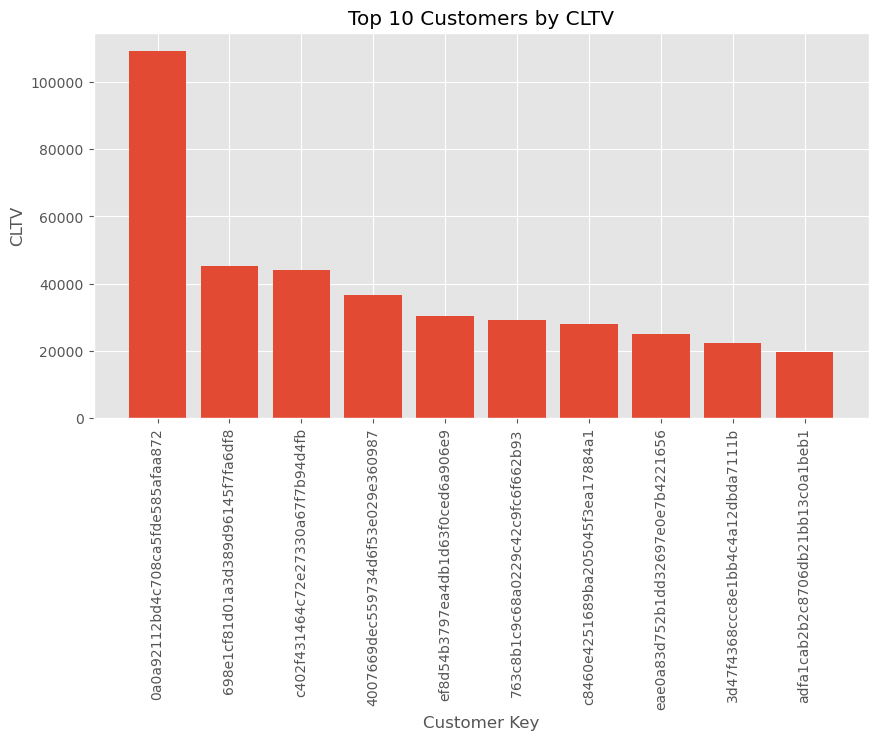

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    top_customers['customer_key'],
    top_customers['cltv']
)

plt.title('Top 10 Customers by CLTV')
plt.xlabel('Customer Key')
plt.ylabel('CLTV')

plt.xticks(rotation=90)

plt.show()

### CLTV Distribution

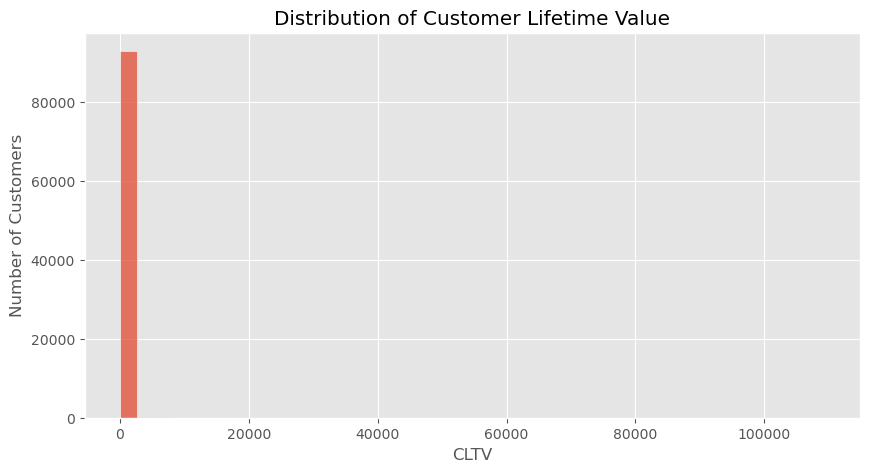

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_summary['cltv'],
    bins=40
)

plt.title('Distribution of Customer Lifetime Value')
plt.xlabel('CLTV')
plt.ylabel('Number of Customers')

plt.show()

In [22]:
cltv_df.columns

Index(['customer_key', 'order_id', 'purchase_datetime', 'total_payment'], dtype='object')

In [23]:
customer_summary.columns

Index(['customer_key', 'total_orders', 'total_revenue', 'first_purchase',
       'last_purchase', 'customer_lifespan_days', 'average_order_value',
       'purchase_frequency', 'cltv', 'customer_segment'],
      dtype='object')

In [24]:
customer_summary.to_csv(
    "customer_cltv.csv",
    index=False
)